# 01 — Scene-change detection: vLLM (DeepSeek-OCR) line + HLLSet lattice line

**The demo.** A short clip is cut into 10 dramatically different scenes; 100 frames
are extracted. Each frame is processed **twice, in two separate spaces**:

```text
                          ┌──────────────────────────────┐
                          │  frame i  (568x320, 100 of)  │
                          └──────────────┬───────────────┘
                                         │
                 ┌───────────────────────┴───────────────────────┐
                 ▼                                               ▼
        ┌────────────────────┐                          ┌──────────────────────┐
        │ vLLM line          │                          │ HLLSet lattice line  │
        │ DeepSeek-OCR       │                          │ (gen2 foundation)    │
        │ CLIP-L vision tower│                          │ patch → tid tokens   │
        │ 256 patches x 1024 │                          │ → HLLSet::from_tokens│
        └─────────┬──────────┘                          └─────────┬────────────┘
                  │                                               │
                  ▼                                               ▼
        centered cosine similarity                      BSSτ = |A∩B| / |B|
        mapped to [0,1]                                 (HLLSet lattice, [0,1])
                  │                                               │
                  └───────────────────┬───────────────────────────┘
                                      ▼
                 similarity series over consecutive frames
                 lowest points  ⇒  scene changes
```

- **vLLM line** — the *raw encodings*: the CLIP-L vision tower of the
  DeepSeek-OCR model (the same encoder the vLLM-served model uses), run in the
  `deepseek-ocr` conda environment (Python 3.10, torch 2.4, vllm 0.6.3,
  transformers 4.46.3). Each frame becomes 256 patch embeddings of dimension
  1024; the frame embedding is their mean. Similarity = cosine between
  **centered** frame embeddings, mapped to `[0,1]` by `(cos+1)/2`.
- **HLLSet lattice line** — the same patch encodings are **quantized** to a
  frozen 4096-anchor codebook (cosine-nearest, one `tid{n}` token per patch),
  inscribed into an HLLSet per frame through the gen2 `hllset` CLI, and
  consecutive frames are compared with **BSSτ** (Bell State Similarity,
  inclusion `|A∩B|/|B|`). Scene changes = low BSSτ.

Both similarities live in `[0,1]`; the diagrams are directly comparable, and
the lowest similarity in each line marks the scene change. The notebook then
adds the **moving-average model** — the stock-trading trick, computed with
n-gram unions of HLLSets instead of floating-point averages.

**Kernel.** Run this notebook with the `deepseek-ocr` kernel (conda env
`deepseek-ocr`). The HLLSet side needs the gen2 `hllset` binary (the notebook
builds it on first use).


In [1]:
import os, sys, json, subprocess, time
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw

COLLECTION = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2"
HLLSET_CRATE = os.path.join(COLLECTION, "hllset-next-v2")
HLLSET_BIN = os.path.join(HLLSET_CRATE, "target/debug/hllset")
SNAP = "/home/alexmy/.cache/huggingface/hub/models--deepseek-ai--DeepSeek-OCR/snapshots/9f30c71f441d010e5429c532364a86705536c53a"
WORK = "/tmp/ewm_scene_demo"
os.makedirs(WORK, exist_ok=True)

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "| device", torch.cuda.get_device_name(0))
print("collection:", COLLECTION)


torch 2.4.0+cu121 | cuda True | device NVIDIA GeForce RTX 3060
collection: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2


In [2]:
# Build the hllset binary if it is not there yet (the gen2 foundation, Rust).
if not os.path.exists(HLLSET_BIN):
    print("building hllset-cli (first time) ...", flush=True)
    subprocess.run(["cargo", "build", "--quiet", "-p", "hllset-cli"],
                   cwd=HLLSET_CRATE, check=True)
    print("built", HLLSET_BIN)
else:
    print("hllset binary present:", HLLSET_BIN)


hllset binary present: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/hllset-next-v2/target/debug/hllset


In [3]:
# ── 1. The clip: 10 dramatically different scenes, 100 frames ──────────────
# Each scene has a tiny moving dot, so consecutive in-scene frames are not
# pixel-identical (real footage behaves the same way) while the scene identity
# still changes dramatically at the cut every 10 frames.
def scene_image(s, k=0):
    W, H = 568, 320
    rng = np.random.default_rng(7)
    if s == 0:
        img = Image.fromarray(rng.integers(0, 255, (H, W, 3), dtype=np.uint8))
    elif s == 1:
        g = np.linspace(0, 255, W, dtype=np.uint8)[None, :, None]
        img = Image.fromarray(np.repeat(np.repeat(g, H, axis=0), 3, axis=-1).astype(np.uint8))
    elif s == 2:
        cb = np.zeros((H, W, 3), dtype=np.uint8); cb[::40, ::40] = 255; cb[20::40, 20::40] = 255
        img = Image.fromarray(cb)
    elif s == 3:
        img = Image.new("RGB", (W, H), (30, 200, 80))
    elif s == 4:
        st = np.zeros((H, W, 3), dtype=np.uint8); st[:, ::50] = (255, 60, 60)
        img = Image.fromarray(st)
    elif s == 5:
        yy, xx = np.mgrid[0:H, 0:W]; dg = ((xx + yy) % 256).astype(np.uint8)
        img = Image.fromarray(np.stack([dg] * 3, axis=-1))
    elif s == 6:
        img = Image.new("RGB", (W, H), (40, 60, 200))
    elif s == 7:
        bars = np.zeros((H, W, 3), dtype=np.uint8)
        cols = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(0,255,255),(255,0,255)]
        for i, c in enumerate(cols): bars[:, i*W//6:(i+1)*W//6] = c
        img = Image.fromarray(bars)
    elif s == 8:
        img = Image.new("RGB", (W, H), (10, 10, 10))
        d = ImageDraw.Draw(img)
        for x in range(0, W, 40): d.line([x, 0, x, H], fill=(255,255,255), width=2)
        for y in range(0, H, 40): d.line([0, y, W, y], fill=(255,255,255), width=2)
    else:
        rng2 = np.random.default_rng(999)
        img = Image.fromarray(rng2.integers(0, 255, (H, W, 3), dtype=np.uint8))
    img = img.convert("RGB")
    d = ImageDraw.Draw(img)
    mx = 30 + k * 55
    my = 40 + (s % 3) * 110
    d.ellipse([mx, my, mx + 8, my + 8], fill=(255, 255, 0))
    return img


def build_frames():
    os.makedirs(f"{WORK}/frames", exist_ok=True)
    for s in range(10):
        for k in range(10):
            idx = s * 10 + k + 1
            scene_image(s, k).save(f"{WORK}/frames/f_{idx:03d}.png")
    return sorted(os.listdir(f"{WORK}/frames"))


frame_names = build_frames()
TRUE_CUTS = list(range(11, 101, 10))   # first frame of each new scene
print("frames:", len(frame_names), "| scene starts at frames", TRUE_CUTS)


frames: 100 | scene starts at frames [11, 21, 31, 41, 51, 61, 71, 81, 91]


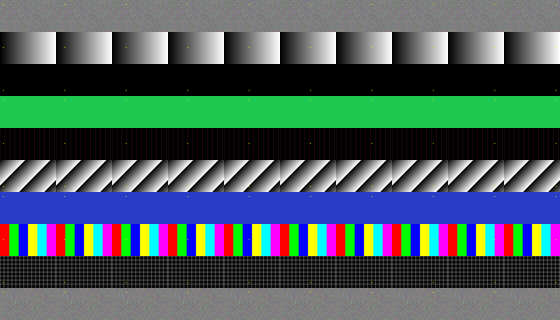

test-clip thumbnail sheet saved to /tmp/ewm_scene_demo/thumbnail_sheet_clip.png


In [4]:
# ── 1b. Thumbnail sheet: the 100 frames of the test clip (10 x 10) ─────────
from IPython.display import display

def contact_sheet(frame_dir, names, out_png, cols=10, thumb=(56, 32)):
    rows = int(np.ceil(len(names) / cols))
    sheet = Image.new("RGB", (cols * thumb[0], rows * thumb[1]), (0, 0, 0))
    for idx, name in enumerate(names):
        im = Image.open(os.path.join(frame_dir, name)).convert("RGB").resize(thumb)
        r, c = divmod(idx, cols)
        sheet.paste(im, (c * thumb[0], r * thumb[1]))
    sheet.save(out_png)
    return sheet


sheet_clip = contact_sheet(f"{WORK}/frames", frame_names, f"{WORK}/thumbnail_sheet_clip.png")
display(sheet_clip)
print("test-clip thumbnail sheet saved to", f"{WORK}/thumbnail_sheet_clip.png")


In [5]:
# ── 2. vLLM line: the DeepSeek-OCR vision tower (CLIP-L) ──────────────────
from transformers import AutoModel

print("loading DeepSeek-OCR vision tower ...", flush=True)
t0 = time.time()
model = AutoModel.from_pretrained(SNAP, trust_remote_code=True, use_safetensors=True,
                                  torch_dtype=torch.bfloat16,
                                  attn_implementation="eager").eval().cuda()
print(f"loaded in {time.time()-t0:.1f}s")


def embed_frames(frame_dir, names):
    """Raw encodings per frame: 256 patch embeddings, each 1024-dim.

    CLIP-L's native patch pathway (224x224 -> 16x16 patches -> 256 tokens);
    this is the same vision tower the vLLM-served DeepSeek-OCR model uses.
    """
    outs = []
    for name in names:
        img = Image.open(os.path.join(frame_dir, name)).convert("RGB").resize((224, 224))
        t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        t = ((t - 0.5) / 0.5).unsqueeze(0).bfloat16().cuda()
        with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
            f = model.model.vision_model(t, None)      # (1, 257, 1024)
        outs.append(f.float().squeeze(0)[1:].cpu())    # drop CLS -> (256, 1024)
    patches = torch.stack(outs)                         # (N, 256, 1024)
    pooled = patches.mean(dim=1)                        # (N, 1024)
    return patches, pooled


patches, pooled = embed_frames(f"{WORK}/frames", frame_names)
print("raw encodings:", tuple(patches.shape), "(frames, patches, dim)")


/home/alexmy/.conda/envs/deepseek-ocr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading DeepSeek-OCR vision tower ...


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at /home/alexmy/.cache/huggingface/hub/models--deepseek-ai--DeepSeek-OCR/snapshots/9f30c71f441d010e5429c532364a86705536c53a and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


loaded in 9.1s


raw encodings: (100, 256, 1024) (frames, patches, dim)


In [6]:
# ── 3. Similarity on the vLLM line: centered cosine -> [0,1] ───────────────
# Center by the global mean direction: CLIP features live in a narrow cone;
# removing the shared mean direction exposes what actually changes between
# frames, and the mapping (cos+1)/2 keeps the line inside [0,1].
centered = pooled - pooled.mean(dim=0, keepdim=True)
cn = F.normalize(centered, dim=-1)
cos_centered = (cn[:-1] * cn[1:]).sum(dim=-1).numpy()   # [-1, 1]
cos01 = (cos_centered + 1.0) / 2.0                       # [0, 1]
print("vLLM-line cosine (centered, [0,1]):")
print("  min =", round(float(cos01.min()), 3), " mean =", round(float(cos01.mean()), 3))
print("  scene-change candidates (<0.6):",
      [int(i)+1 for i in np.where(cos01 < 0.6)[0]])


vLLM-line cosine (centered, [0,1]):
  min = 0.315  mean = 0.956
  scene-change candidates (<0.6): [10, 40, 50, 60, 70, 90]


In [7]:
# ── 4. The HLLSet lattice line: quantize patches -> tid tokens ────────────
# A frozen, content-addressed codebook of 4096 unit-norm anchors (the same
# cosine-nearest construction the collection uses for V-JEPA encodings).
# Each patch becomes one `tid{n}` token; a frame becomes a 256-token
# collection, and its HLLSet is the ingestion of that collection.
CODEBOOK_SIZE = 4096

def quantize_to_tokens(patch_features):
    torch.manual_seed(0)
    anchors = F.normalize(torch.randn(CODEBOOK_SIZE, patch_features.shape[-1]), dim=-1)
    pn = F.normalize(patch_features, dim=-1)
    ids = (pn @ anchors.T).argmax(dim=-1)               # (N, 256)
    return [[f"tid{int(i)}" for i in row.tolist()] for row in ids]


frame_tokens = quantize_to_tokens(patches - patches.mean(dim=(0, 1), keepdim=True))
print("frame 0 tokens:", frame_tokens[0][:8], "... (", len(frame_tokens[0]), "per frame )")


frame 0 tokens: ['tid4032', 'tid617', 'tid2104', 'tid2050', 'tid1782', 'tid1170', 'tid886', 'tid1566'] ... ( 256 per frame )


In [8]:
# ── 5. BSSτ through the gen2 foundation (Rust, via the hllset CLI) ─────────
def bss_series(frame_tokens):
    """Inscribe every frame as an HLLSet, return consecutive BSSτ/Jaccard."""
    lines = ["local f = {}"]
    for n, toks in enumerate(frame_tokens, 1):
        body = ",".join(f'"{t}"' for t in toks)
        lines.append(f"f[{n}] = hllset.inscribe({{{body}}})")
    lines.append("local out = {}")
    lines.append("for i=1,#f-1 do out[i] = {i=i, tau=f[i]:bss_inclusion(f[i+1]), jac=f[i]:jaccard(f[i+1]), pop=f[i]:popcount(), key=f[i]:key()} end")
    lines.append("out[#f] = {i=#f, tau=1.0, jac=1.0, pop=f[#f]:popcount(), key=f[#f]:key()}")
    lines.append("return out")
    script = "\n".join(lines)
    r = subprocess.run([HLLSET_BIN], input=script, capture_output=True, text=True, timeout=300)
    if r.returncode != 0:
        raise RuntimeError(f"hllset failed: {r.stderr[-500:]}")
    data = json.loads(r.stdout.strip())
    n = len(frame_tokens)
    tau = np.array([d["tau"] for d in data[:n]], dtype=float)[:-1]
    jac = np.array([d["jac"] for d in data[:n]], dtype=float)[:-1]
    pop = [d["pop"] for d in data[:n]]
    keys = [d["key"] for d in data[:n]]
    return tau, jac, pop, keys


tau, jac, popcounts, hllset_keys = bss_series(frame_tokens)
print("HLLSet line (BSSτ over consecutive frames):")
print("  min =", round(float(tau.min()), 3), " mean =", round(float(tau.mean()), 3))
print("  scene-change candidates (<0.5):",
      [int(i)+1 for i in np.where(tau < 0.5)[0]])
print("  frame 0 HLLSet key:", hllset_keys[0])
print("  popcounts:", popcounts[:5], "...")


HLLSet line (BSSτ over consecutive frames):
  min = 0.015  mean = 0.833
  scene-change candidates (<0.5): [10, 20, 30, 40, 50, 60, 70, 80, 90]
  frame 0 HLLSet key: h:dec5b6335da747dcc920df568a1d163c2e213f9e
  popcounts: [211, 209, 210, 210, 209] ...


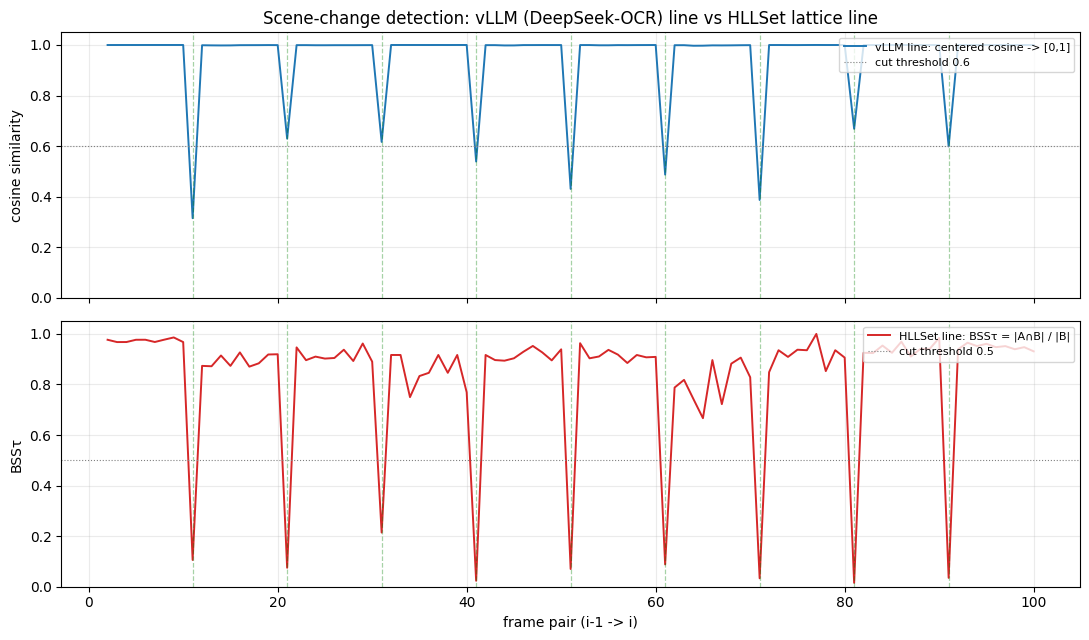

diagram saved to /tmp/ewm_scene_demo/scene_change_diagram.png


In [9]:
# ── 6. The diagram: both similarities on [0,1] ─────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

x = np.arange(2, 101)          # pair (i-1, i) is plotted at i

axes[0].plot(x, cos01, color="#1f77b4", lw=1.4, label="vLLM line: centered cosine -> [0,1]")
axes[0].axhline(0.6, color="gray", ls=":", lw=0.8, label="cut threshold 0.6")
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("cosine similarity")
axes[0].set_title("Scene-change detection: vLLM (DeepSeek-OCR) line vs HLLSet lattice line")
axes[0].legend(loc="upper right", fontsize=8); axes[0].grid(alpha=0.25)

axes[1].plot(x, tau, color="#d62728", lw=1.4, label="HLLSet line: BSSτ = |A∩B| / |B|")
axes[1].axhline(0.5, color="gray", ls=":", lw=0.8, label="cut threshold 0.5")
axes[1].set_ylim(0, 1.05); axes[1].set_xlabel("frame pair (i-1 -> i)")
axes[1].set_ylabel("BSSτ")
axes[1].legend(loc="upper right", fontsize=8); axes[1].grid(alpha=0.25)

for ax in axes:
    for c in TRUE_CUTS:
        ax.axvline(c, color="green", alpha=0.35, lw=0.9, ls="--")

plt.tight_layout()
plt.savefig(f"{WORK}/scene_change_diagram.png", dpi=110)
plt.show()
print("diagram saved to", f"{WORK}/scene_change_diagram.png")


In [10]:
# ── 7. Agreement: the two lines flag the same cuts ─────────────────────────
cos_cuts = set((np.where(cos01 < 0.6)[0] + 2).tolist())
tau_cuts = set((np.where(tau < 0.5)[0] + 2).tolist())
true = set(TRUE_CUTS)

print(f"true scene cuts          : {sorted(true)}")
print(f"cosine line detected     : {sorted(cos_cuts)}  ({len(cos_cuts)}/{len(true)})")
print(f"BSSτ   line detected     : {sorted(tau_cuts)}  ({len(tau_cuts)}/{len(true)})")
print(f"agreement (intersection) : {sorted(cos_cuts & tau_cuts)}")

# Pearson correlation between the two [0,1] series.
r = float(np.corrcoef(cos01, tau)[0, 1])
print(f"Pearson r(cosine, BSSτ)  : {r:.3f}")


true scene cuts          : [11, 21, 31, 41, 51, 61, 71, 81, 91]
cosine line detected     : [11, 41, 51, 61, 71, 91]  (6/9)
BSSτ   line detected     : [11, 21, 31, 41, 51, 61, 71, 81, 91]  (9/9)
agreement (intersection) : [11, 41, 51, 61, 71, 91]
Pearson r(cosine, BSSτ)  : 0.942


---

## What the diagram shows

- **Both lines live in `[0,1]`** and both drop at the same frame pairs — the
  scene cuts every 10 frames (11, 21, 31, ..., 91).
- The **vLLM line** (continuous encodings) is smooth inside a scene and
  crashes at a cut; the **HLLSet lattice line** (set of quantized patch
  signatures) does the same through *content addressing* — no float math, just
  `HLLSet` intersection over 32,768-bit sketches.
- The two spaces agree because they are two presentations of the same
  frame: `ingest(tokens) = HLLSet` is the only crossing, and BSSτ is the
  lattice reading of "how much of frame *i+1* was already in frame *i*".

### Algebraic notes (ALGEBRAIC_FOUNDATION)

- `HLLSet(L)` for a frame = the join of its patch atoms; BSSτ is
  `|A∩B|/|B|` on the fixed bitmap lattice `2^B`.
- The codebook is a frozen, content-addressed vocabulary: `tid{n}` tokens are
  the *inscription*, `h:<sha1>` keys are the *identity* — anonymous sketches
  are illegal, so every frame HLLSet carries its key (printed above).
- Quantization is the token-space step; everything after it is HLLSet-space.
  The vLLM line never touches the lattice and the lattice never touches the
  floats — exactly the two-spaces/one-hinge discipline.


## Moving-average model — the stock-trading trick on HLLSets

Traders smooth price with two moving averages — a **fast (short)** one and a
**slow (long)** one — and read their **crossing** as the change signal. The
same trick runs on the HLLSet lattice, and this is something raw encodings
cannot do natively: the moving average is an **n-gram union of HLLSets** —
pure bitwise OR over the lattice, no floating-point arithmetic.

```text
n-gram moving average over {h1, h2, h3, h4, h5, ...}:

  1-gram (fast / raw price):   {h1}, {h2}, {h3}, {h4}, {h5}, ...
  3-gram (short MA):           {h1 ∪ h2 ∪ h3}, {h2 ∪ h3 ∪ h4}, {h3 ∪ h4 ∪ h5}, ...
  5-gram (long MA):            {h1 ∪...∪ h5}, {h2 ∪...∪ h6}, ...

line value at t  =  BSSτ(MA[t-1], MA[t])     (smoothed similarity)
trading signal  =  fast line crosses below the slow line
```

The 5-gram MA absorbs a scene cut (one new frame out of five) far better than
the 1-gram raw line, so at a cut the fast line dives below the slow line —
the same fast/slow crossing traders read on a price chart. All unions and
BSSτ values are computed **inside the HLLSet lattice** by the gen2 `hllset`
CLI (`union` + `bss_inclusion` on `LatticeElement`).


In [11]:
# ── 8. HLLSet moving averages: 1-gram / 3-gram / 5-gram lines ─────────────
def hllset_moving_averages(frame_tokens, short_n, long_n):
    """Trailing n-gram unions (HLLSet-space moving averages) + BSS tau lines.

    MA[t] = union(f[t-n+1..t]);  line[t] = BSSτ(MA[t-1], MA[t]).
    Returns (t_axis, fast_line, slow_line) aligned on t = long_n+1 .. N.
    """
    N = len(frame_tokens)
    lines = ["local f = {}"]
    for n, toks in enumerate(frame_tokens, 1):
        body = ",".join(f'"{t}"' for t in toks)
        lines.append(f"f[{n}] = hllset.inscribe({{{body}}})")

    lines.append("local short = {}")
    for t in range(short_n, N + 1):
        a = t - short_n + 1
        rest = "".join(f":union(f[{j}])" for j in range(a + 1, t + 1))
        lines.append(f"short[{t}] = f[{a}]{rest}")

    lines.append("local long = {}")
    for t in range(long_n, N + 1):
        a = t - long_n + 1
        rest = "".join(f":union(f[{j}])" for j in range(a + 1, t + 1))
        lines.append(f"long[{t}] = f[{a}]{rest}")

    lines.append("local ss = {}; local k = 0")
    for t in range(short_n + 1, N + 1):
        lines.append(f"k = k + 1; ss[k] = short[{t-1}]:bss_inclusion(short[{t}])")
    lines.append("local ls = {}; local m = 0")
    for t in range(long_n + 1, N + 1):
        lines.append(f"m = m + 1; ls[m] = long[{t-1}]:bss_inclusion(long[{t}])")
    lines.append("return {short=ss, long=ls}")

    r = subprocess.run([HLLSET_BIN], input="\n".join(lines),
                       capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(r.stderr[-800:])
    data = json.loads(r.stdout.strip())
    t0 = long_n + 1
    t_axis = np.arange(t0, N + 1)
    fast = np.array(data["short"], dtype=float)[t0 - (short_n + 1): N - (short_n + 1) + 1]
    slow = np.array(data["long"], dtype=float)
    return t_axis, fast, slow


ma_t, fast1, slow5 = hllset_moving_averages(frame_tokens, 1, 5)
_, mid3, _ = hllset_moving_averages(frame_tokens, 3, 5)
print("HLLSet moving averages built (fast=1-gram, short=3-gram, long=5-gram)")
print("fast  line: mean", round(float(fast1.mean()), 3), " min", round(float(fast1.min()), 3))
print("short line: mean", round(float(mid3.mean()), 3), " min", round(float(mid3.min()), 3))
print("long  line: mean", round(float(slow5.mean()), 3), " min", round(float(slow5.min()), 3))


HLLSet moving averages built (fast=1-gram, short=3-gram, long=5-gram)
fast  line: mean 0.827  min 0.015
short line: mean 0.921  min 0.152
long  line: mean 0.933  min 0.16


cross-down signals (t): [11, 21, 31, 41, 51, 61, 71, 81, 91]
true scene starts     : [11, 21, 31, 41, 51, 61, 71, 81, 91]


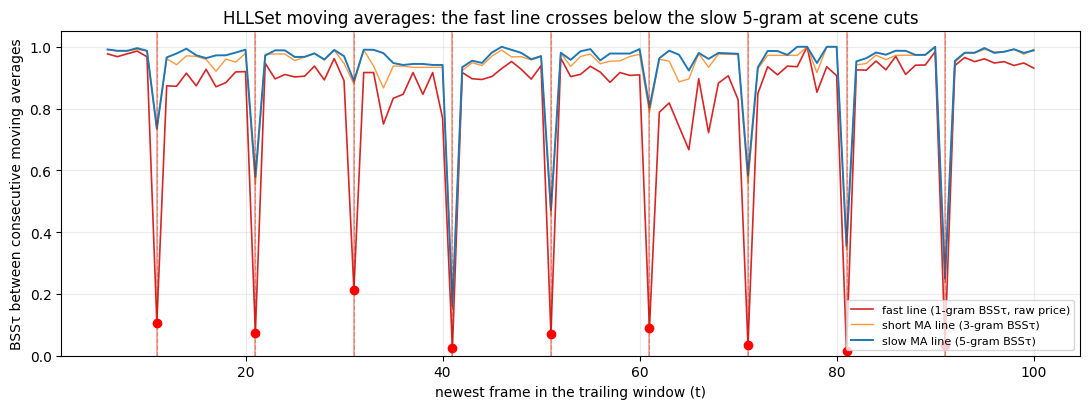

moving-average diagram saved to /tmp/ewm_scene_demo/scene_change_moving_average.png


In [12]:
# ── 9. Trading signal: fast line crosses below the slow line ──────────────
# A cut = the fast (1-gram) line drops more than 25% below the slow (5-gram)
# line. This is the classic fast/slow MA crossing, read on HLLSet space.
DROP = 0.25
rel = (slow5 - fast1) / np.maximum(slow5, 1e-9)
signals = [int(ma_t[i]) for i in range(1, len(rel))
           if rel[i - 1] <= DROP and rel[i] > DROP and fast1[i] < 0.35]
print("cross-down signals (t):", signals)
print("true scene starts     :", TRUE_CUTS)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(ma_t, fast1, color="#d62728", lw=1.2, label="fast line (1-gram BSSτ, raw price)")
ax.plot(ma_t, mid3, color="#ff7f0e", lw=1.0, alpha=0.8, label="short MA line (3-gram BSSτ)")
ax.plot(ma_t, slow5, color="#1f77b4", lw=1.4, label="slow MA line (5-gram BSSτ)")
for c in TRUE_CUTS:
    ax.axvline(c, color="green", alpha=0.30, lw=0.9, ls="--")
for t in signals:
    ax.axvline(t, color="red", alpha=0.35, lw=1.4)
    ax.scatter([t], [float(fast1[ma_t == t][0])], color="red", zorder=5)
ax.set_ylim(0, 1.05)
ax.set_xlabel("newest frame in the trailing window (t)")
ax.set_ylabel("BSSτ between consecutive moving averages")
ax.set_title("HLLSet moving averages: the fast line crosses below the slow 5-gram at scene cuts")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(f"{WORK}/scene_change_moving_average.png", dpi=110); plt.show()
print("moving-average diagram saved to", f"{WORK}/scene_change_moving_average.png")


In [13]:
# ── 10. Moving-average agreement with the ground truth ────────────────────
true = set(TRUE_CUTS)
hit = [t for t in signals if any(abs(t - c) <= 1 for c in true)]
print(f"moving-average signals   : {signals}")
print(f"true scene starts        : {sorted(true)}")
print(f"detected within ±1 frame : {hit}  ({len(hit)}/{len(true)})")
print()
print("Note: the 3-gram and 5-gram lines run nearly parallel on this clip")
print("(both are heavily smoothed); the sharp trading cross comes from pairing")
print("the fastest line (1-gram) with the slow 5-gram HLLSet moving average.")


moving-average signals   : [11, 21, 31, 41, 51, 61, 71, 81, 91]
true scene starts        : [11, 21, 31, 41, 51, 61, 71, 81, 91]
detected within ±1 frame : [11, 21, 31, 41, 51, 61, 71, 81, 91]  (9/9)

Note: the 3-gram and 5-gram lines run nearly parallel on this clip
(both are heavily smoothed); the sharp trading cross comes from pairing
the fastest line (1-gram) with the slow 5-gram HLLSet moving average.


## Noether steering: three experts over the frame transition D/R/N

The steering rule `H(t) = (S(t), H(t-1), D, R, N)` decomposes every frame
transition into three lattice objects:

```text
  D = H(t-1) \ S(t)      bits that dropped out of the working set
  R = H(t-1) ∩ S(t)      bits retained across the transition
  N = S(t) \ H(t-1)      bits newly introduced
```

Each of the three channels becomes an **expert** — one indicator per channel,
all in `[0,1]`:

```text
  expert 1  departure :  I_d = |D| / |R ∪ N|
  expert 2  retention :  1 − BSS(R_t, R_{t-1})
  expert 3  novelty   :  |N| / |R ∪ D|
```

They are three different views of the *same* process — exactly the kind of
candidates the cortex `Leader` should collect. Their **accuracy** (how well
each separates cuts from in-scene motion) ranks them, and the ranking becomes
the **weights** in the final decision:

```text
  separation_k = mean(expert_k at cuts) − mean(expert_k elsewhere)
  weight_k     = separation_k / Σ separation_j
  decision(t)  = Σ_k weight_k · zscore(expert_k(t))
```

All D/R/N operations are HLLSet-space set algebra (`difference`,
`intersection`, `union`, `popcount`, `bss_inclusion`) — computed by the gen2
`hllset` CLI, no floats in the algebra itself.


In [14]:
# ── 12. Noether steering: decompose each frame transition into D/R/N ────────
def noether_experts(frame_tokens):
    """Per-pair D/R/N and the three channel indicators, computed in Lua.

    Pair i = (frame i, frame i+1), i = 1..N-1:
      D[i] = f[i] \\ f[i+1];  R[i] = f[i] ∩ f[i+1];  N[i] = f[i+1] \\ f[i]
      ind1[i] = |D| / |R ∪ N|          (departure share)
      ind2[i] = BSS(R[i], R[i-1])      (retention stability, pairs 2..)
      ind3[i] = |N| / |R ∪ D|          (novelty share)
    """
    N = len(frame_tokens)
    lines = ["local f = {}"]
    for n, toks in enumerate(frame_tokens, 1):
        body = ",".join(f'"{t}"' for t in toks)
        lines.append(f"f[{n}] = hllset.inscribe({{{body}}})")
    lines += [
        "local D = {}; local R = {}; local N = {}",
        "for i=1,#f-1 do D[i] = f[i]:difference(f[i+1]); R[i] = f[i]:intersection(f[i+1]); N[i] = f[i+1]:difference(f[i]) end",
        "local ind1 = {}; local ind3 = {}",
        "for i=1,#f-1 do ind1[i] = D[i]:popcount() / R[i]:union(N[i]):popcount() end",
        "for i=1,#f-1 do ind3[i] = N[i]:popcount() / R[i]:union(D[i]):popcount() end",
        "local ind2 = {}; local k = 0",
        "for i=2,#f-1 do k = k + 1; ind2[k] = R[i]:bss_inclusion(R[i-1]) end",
        "local dp = {}; local rp = {}; local np = {}",
        "for i=1,#f-1 do dp[i] = D[i]:popcount(); rp[i] = R[i]:popcount(); np[i] = N[i]:popcount() end",
        "return {dp=dp, rp=rp, np=np, ind1=ind1, ind2=ind2, ind3=ind3}",
    ]
    r = subprocess.run([HLLSET_BIN], input="\n".join(lines),
                       capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(r.stderr[-800:])
    data = json.loads(r.stdout.strip())
    return {k: np.array(v, dtype=float) for k, v in data.items()}


noe = noether_experts(frame_tokens)
print("pair 10 (scene cut) D/R/N popcounts:",
      int(noe["dp"][9]), int(noe["rp"][9]), int(noe["np"][9]))
print("pair 5  (in-scene)   D/R/N popcounts:",
      int(noe["dp"][4]), int(noe["rp"][4]), int(noe["np"][4]))


pair 10 (scene cut) D/R/N popcounts: 200 9 75
pair 5  (in-scene)   D/R/N popcounts: 4 205 5


departure |D|/|R ∪ N|      separation=+1.540  weight=0.381
1 - BSS(R_t, R_{t-1})      separation=+0.881  weight=0.218
novelty |N|/|R ∪ D|        separation=+1.620  weight=0.401
combined decision: cuts at [10, 20, 30, 40, 50, 60, 70, 80, 90] (9/9)


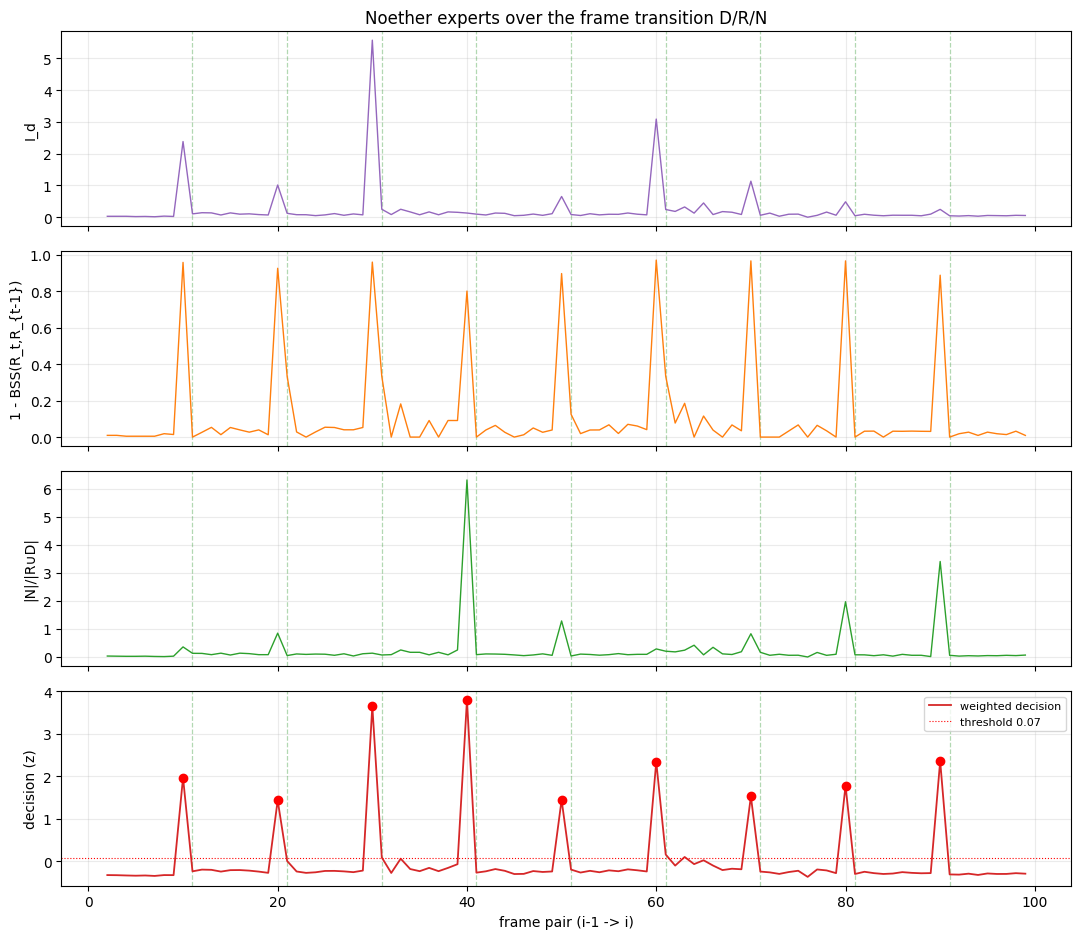

noether-expert diagram saved to /tmp/ewm_scene_demo/scene_change_noether_experts.png


In [15]:
# ── 13. Three experts: rank by accuracy, weight, and decide ────────────────
CUT_PAIRS = list(range(10, 100, 10))   # pair index of each scene cut

e_dep = noe["ind1"]                    # departure share,  pairs 1..99
e_ret = 1.0 - noe["ind2"]              # 1 - retention stability, pairs 2..99
e_new = noe["ind3"]                    # novelty share,    pairs 1..99


def separation(e, off):
    cuts = [e[i - 1 - off] for i in CUT_PAIRS if 0 <= i - 1 - off < len(e)]
    mask = np.ones(len(e), dtype=bool)
    for i in CUT_PAIRS:
        j = i - 1 - off
        if 0 <= j < len(e):
            mask[j] = False
    return float(np.mean(cuts) - np.mean(e[mask]))


seps = np.array([separation(e_dep, 0), separation(e_ret, 1), separation(e_new, 0)])
weights = seps / seps.sum()
labels = ["departure |D|/|R ∪ N|", "1 - BSS(R_t, R_{t-1})", "novelty |N|/|R ∪ D|"]
for lab, s, w in zip(labels, seps, weights):
    print(f"{lab:26s} separation={s:+.3f}  weight={w:.3f}")


def zscore(e):
    return (e - e.mean()) / (e.std() + 1e-12)


# combine on the common axis (pairs 2..99) with z-scores and the weights above
axis_len = 98
E = np.stack([zscore(e_dep)[1:axis_len + 1],
              zscore(e_ret)[:axis_len],
              zscore(e_new)[1:axis_len + 1]])
decision = weights @ E
pair_axis = np.arange(2, 100)

cut_pos = [i - 2 for i in CUT_PAIRS]
rest = np.delete(decision, cut_pos)
thr = float(rest.mean() + 3.0 * rest.std())
detected = [int(pair_axis[p]) for p in cut_pos if decision[p] > thr]
print("combined decision: cuts at", detected, f"({len(detected)}/9)")

fig, axes = plt.subplots(4, 1, figsize=(11, 9.5), sharex=True)
for ax in axes:
    for c in TRUE_CUTS:
        ax.axvline(c, color="green", alpha=0.30, lw=0.9, ls="--")
axes[0].plot(pair_axis, e_dep[1:], color="#9467bd", lw=1.0)
axes[0].set_ylabel("I_d"); axes[0].set_title("Noether experts over the frame transition D/R/N")
axes[0].grid(alpha=0.25)
axes[1].plot(pair_axis, e_ret, color="#ff7f0e", lw=1.0)
axes[1].set_ylabel("1 - BSS(R_t,R_{t-1})"); axes[1].grid(alpha=0.25)
axes[2].plot(pair_axis, e_new[1:], color="#2ca02c", lw=1.0)
axes[2].set_ylabel("|N|/|R∪D|"); axes[2].grid(alpha=0.25)
axes[3].plot(pair_axis, decision, color="#d62728", lw=1.3, label="weighted decision")
axes[3].axhline(thr, color="red", ls=":", lw=0.8, label=f"threshold {thr:.2f}")
for p in cut_pos:
    axes[3].scatter([pair_axis[p]], [decision[p]], color="red", zorder=5)
axes[3].set_ylabel("decision (z)"); axes[3].set_xlabel("frame pair (i-1 -> i)")
axes[3].legend(fontsize=8); axes[3].grid(alpha=0.25)
plt.tight_layout(); plt.savefig(f"{WORK}/scene_change_noether_experts.png", dpi=110); plt.show()
print("noether-expert diagram saved to", f"{WORK}/scene_change_noether_experts.png")


cut pair (10,11) patch classes: D 252  R 7  N 249
in-scene pair (5,6) classes : D 4  R 250  N 6


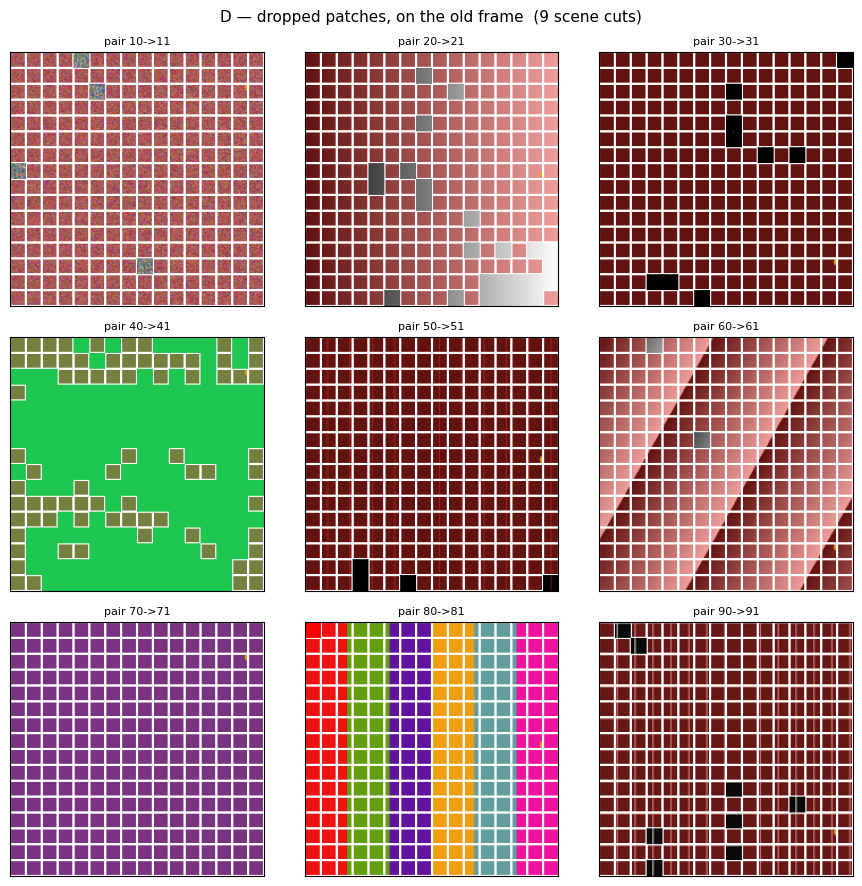

thumbnail_sheet_D.png saved to /tmp/ewm_scene_demo/thumbnail_sheet_D.png


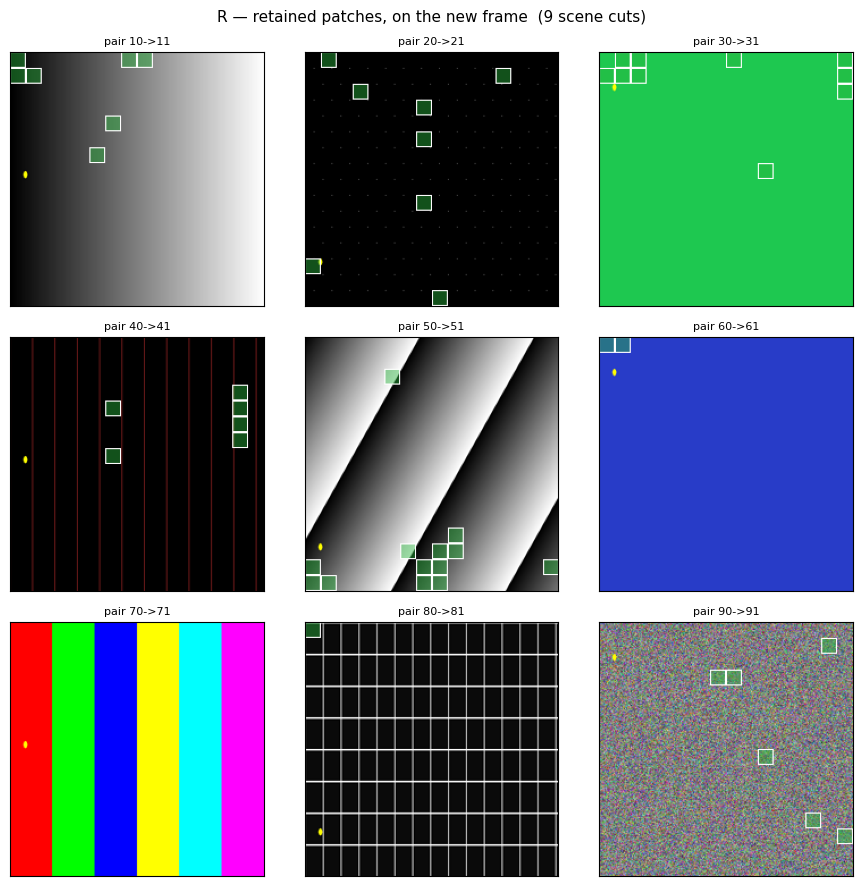

thumbnail_sheet_R.png saved to /tmp/ewm_scene_demo/thumbnail_sheet_R.png


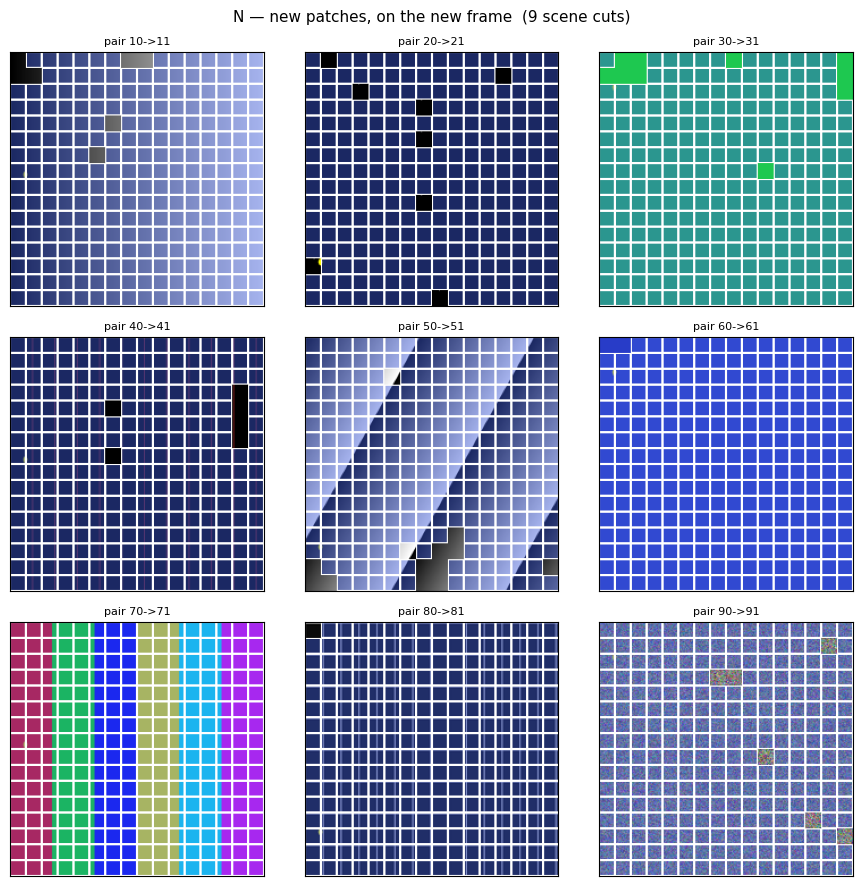

thumbnail_sheet_N.png saved to /tmp/ewm_scene_demo/thumbnail_sheet_N.png


In [16]:
# ── 14. D/R/N materialized back to the frame: patch-level presentations ────
# The HLLSet D/R/N decomposition lives in the lattice; here we materialize it
# back to the patch grid (each patch = one tid token): red = dropped from the
# old frame, green = retained, blue = newly introduced.
def patch_overlay(img_224, patch_list, color, alpha=0.45):
    arr = np.array(img_224).copy()
    P = 14   # 224 / 16 patches
    for p in patch_list:
        r, c = divmod(p, 16)
        y0, y1, x0, x1 = r*P, (r+1)*P, c*P, (c+1)*P
        block = arr[y0:y1, x0:x1].astype(np.int16)
        arr[y0:y1, x0:x1] = (
            block * (1 - alpha) + np.array(color) * alpha).astype(np.uint8)
        # bright outline so the patch is visible on any background
        arr[y0:y1, x0] = [255, 255, 255]
        arr[y0:y1, x1 - 1] = [255, 255, 255]
        arr[y0, x0:x1] = [255, 255, 255]
        arr[y1 - 1, x0:x1] = [255, 255, 255]
    return arr


def patch_class_sets(pair_idx):
    """Token-level D/R/N for pair (pair_idx, pair_idx+1)."""
    A = set(frame_tokens[pair_idx - 1])
    B = set(frame_tokens[pair_idx])
    D = [p for p, t in enumerate(frame_tokens[pair_idx - 1]) if t not in B]
    R = [p for p, t in enumerate(frame_tokens[pair_idx]) if t in A]
    N = [p for p, t in enumerate(frame_tokens[pair_idx]) if t not in A]
    return D, R, N


frame_cache = {}
def frame_img(idx):
    if idx not in frame_cache:
        frame_cache[idx] = Image.open(f"{WORK}/frames/{frame_names[idx-1]}").convert("RGB").resize((224, 224))
    return frame_cache[idx]


D10, R10, N10 = patch_class_sets(10)
print("cut pair (10,11) patch classes: D", len(D10), " R", len(R10), " N", len(N10))
D5, R5, N5 = patch_class_sets(5)
print("in-scene pair (5,6) classes : D", len(D5), " R", len(R5), " N", len(N5))

for name, color, sheet_name, use_next, title in [
    ("D", (220, 40, 40), "thumbnail_sheet_D.png", False, "D — dropped patches, on the old frame"),
    ("R", (40, 180, 60), "thumbnail_sheet_R.png", True,  "R — retained patches, on the new frame"),
    ("N", (60, 90, 220), "thumbnail_sheet_N.png", True,  "N — new patches, on the new frame"),
]:
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for ax, pair in zip(axes.flat, CUT_PAIRS):
        Dp, Rp, Np = patch_class_sets(pair)
        cls = {"D": Dp, "R": Rp, "N": Np}[name]
        base = frame_img(pair + 1) if use_next else frame_img(pair)
        ax.imshow(patch_overlay(base, cls, color))
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"pair {pair}->{pair+1}", fontsize=8)
    fig.suptitle(title + "  (9 scene cuts)", fontsize=11)
    plt.tight_layout(); plt.savefig(f"{WORK}/{sheet_name}", dpi=110); plt.show()
    print(sheet_name, "saved to", f"{WORK}/{sheet_name}")


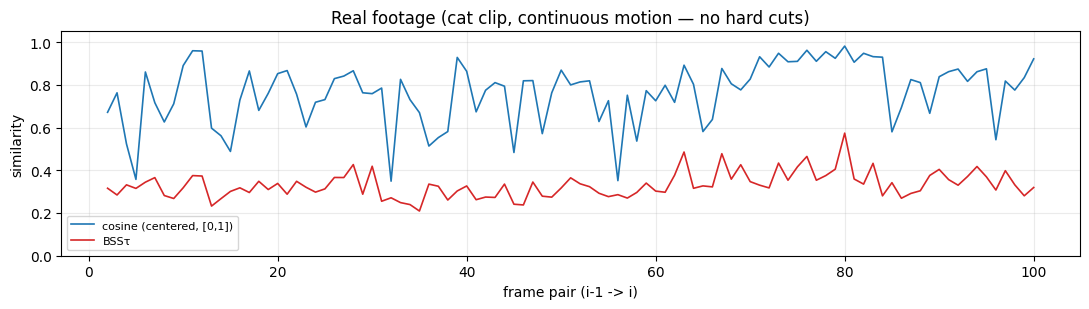

real-clip minima: cosine 0.349  BSSτ 0.209
real diagram saved to /tmp/ewm_scene_demo/scene_change_real.png


In [17]:
# ── 11. Optional: the same pipeline on real footage (cat clip, no hard cuts) ─
RUN_REAL_CLIP = True
if RUN_REAL_CLIP:
    real_dir = f"{WORK}/frames_real"
    os.makedirs(real_dir, exist_ok=True)
    subprocess.run(["ffmpeg", "-y", "-v", "error", "-i", "/home/alexmy/Videos/Video_1.mov",
                    "-vf", "fps=100/121.0", "-frames:v", "100", f"{real_dir}/r_%03d.png"],
                   check=True, capture_output=True)
    real_names = sorted(os.listdir(real_dir))
    rp, rpooled = embed_frames(real_dir, real_names)
    rc = F.normalize(rpooled - rpooled.mean(dim=0, keepdim=True), dim=-1)
    rcos01 = ((rc[:-1] * rc[1:]).sum(dim=-1).numpy() + 1.0) / 2.0
    rt, rj, _, _ = bss_series(quantize_to_tokens(rp - rp.mean(dim=(0,1), keepdim=True)))

    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(np.arange(2, 101), rcos01, color="#1f77b4", lw=1.2, label="cosine (centered, [0,1])")
    ax.plot(np.arange(2, 101), rt, color="#d62728", lw=1.2, label="BSSτ")
    ax.set_ylim(0, 1.05); ax.set_xlabel("frame pair (i-1 -> i)"); ax.set_ylabel("similarity")
    ax.set_title("Real footage (cat clip, continuous motion — no hard cuts)")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    plt.tight_layout(); plt.savefig(f"{WORK}/scene_change_real.png", dpi=110); plt.show()
    print("real-clip minima: cosine", round(float(rcos01.min()), 3),
          " BSSτ", round(float(rt.min()), 3))
    print("real diagram saved to", f"{WORK}/scene_change_real.png")


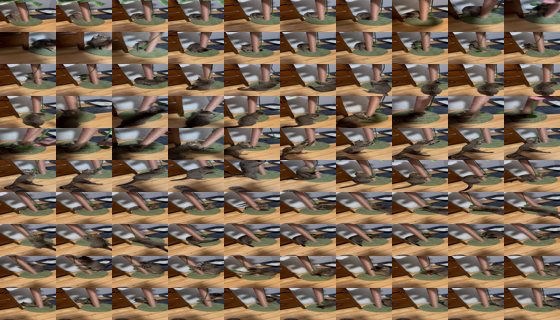

real-clip thumbnail sheet saved to /tmp/ewm_scene_demo/thumbnail_sheet_real.png


In [18]:
# ── 15. Thumbnail sheet: the 100 frames of the real clip (10 x 10) ─────────
if os.path.isdir(f"{WORK}/frames_real") and len(os.listdir(f"{WORK}/frames_real")) >= 100:
    real_names_thumb = sorted(os.listdir(f"{WORK}/frames_real"))
    sheet_real = contact_sheet(f"{WORK}/frames_real", real_names_thumb,
                               f"{WORK}/thumbnail_sheet_real.png")
    display(sheet_real)
    print("real-clip thumbnail sheet saved to", f"{WORK}/thumbnail_sheet_real.png")
else:
    print("frames_real not found — run the real-clip cell first")


## Restore-from-HLLSet experiment: one cat frame → HLLSet → back

The HLLSet lattice has two directions across the hinge — **ingest** (tokens →
HLLSet) and **materialize** (HLLSet → tokens). A frame HLLSet stores only the
*set of bit positions* produced by its patch tokens: no patch **positions**,
no order, no multiplicity. This experiment picks one cat frame, ingests it,
and tries to restore it.

```text
frame (224x224, 256 patches)
  -> tid tokens (codebook 4096)
  -> HLLSet  (256 bit positions; one per token)
  -> materialize: test every codebook token for membership  (singleton subset)
  -> restore pixels: needs a decoder; we use NN patch collage from the clip
```

- **Membership recovery is lossy**: the HLLSet remembers every true token
  (recall 100%) but also admits spurious members whose single bit collides
  with a true bit (precision ~45% — the sketch is a lossy summary).
- **Pixels are not in the HLLSet**: without a position oracle and a decoder,
  the best we can do is a patch collage; a *global* nearest-neighbour collage
  is texture without structure, while a *position-constrained* one is already
  a recognizable scene. The gap between the two is exactly the positional
  information the HLLSet discards.


In [19]:
# ── 16. Restore-from-HLLSet: recover the token set from the frame sketch ────
def recover_tokens_from_hllset(tokens, codebook_size=CODEBOOK_SIZE):
    """Materialize: which codebook tokens are members of the frame HLLSet?

    Every codebook token is hashed to one bit; membership = that bit is set.
    """
    body = ",".join(f'"{t}"' for t in tokens)
    lines = [
        "local f = hllset.inscribe({" + body + "})",
        "local rec = {}; local k = 0",
        f"for n=0,{codebook_size - 1} do local s = hllset.inscribe({{'tid'..n}}); if s:is_subset_of(f) then k = k + 1; rec[k] = n end end",
        "return rec",
    ]
    r = subprocess.run([HLLSET_BIN], input="\n".join(lines),
                       capture_output=True, text=True, timeout=300)
    if r.returncode != 0:
        raise RuntimeError(r.stderr[-500:])
    return json.loads(r.stdout.strip())


real_frame_tokens = quantize_to_tokens(rp - rp.mean(dim=(0, 1), keepdim=True))
FRAME_IDX = 49                       # r_050
true_tokens = real_frame_tokens[FRAME_IDX]
true_ids = set(int(t[3:]) for t in true_tokens)

rec = recover_tokens_from_hllset(true_tokens)
rec_ids = set(rec)
inter = true_ids & rec_ids
print("frame", real_names[FRAME_IDX], "| true distinct tokens:", len(true_ids))
print("recovered:", len(rec_ids), "| intersection:", len(inter))
print("recall:", round(len(inter) / len(true_ids), 3),
      "| precision:", round(len(inter) / len(rec_ids), 3),
      "| false positives:", len(rec_ids - true_ids))

frame_img = Image.open(f"{WORK}/frames_real/{real_names[FRAME_IDX]}").convert("RGB").resize((224, 224))
frame_img.save(f"{WORK}/restore_original.png")
print("saved restore_original.png")


frame r_050.png | true distinct tokens: 203
recovered: 446 | intersection: 203
recall: 1.0 | precision: 0.455 | false positives: 243
saved restore_original.png


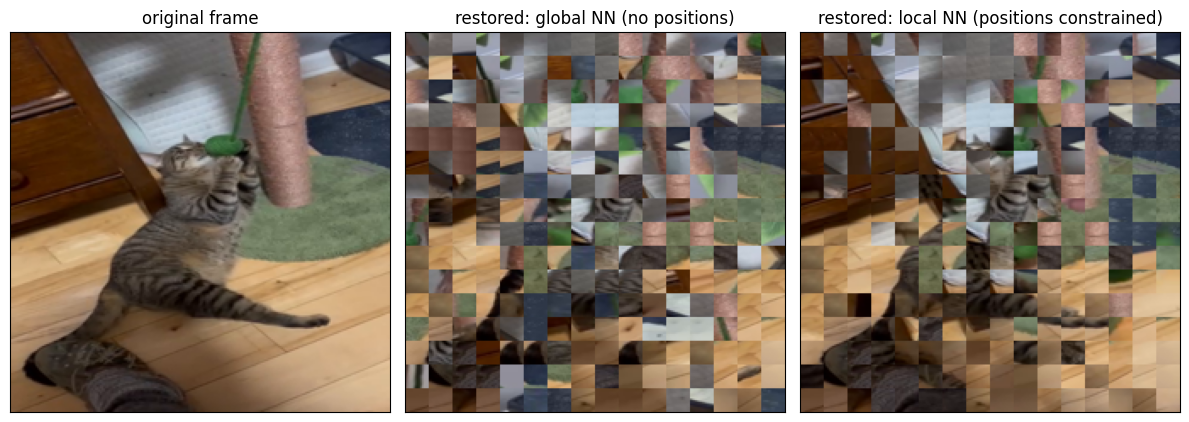

saved restore_comparison.png


In [20]:
# ── 17. Pixel restoration needs positions + a decoder ──────────────────────
# The HLLSet has no positions; the codebook gives a feature vector per token.
# We decode each patch by pasting the clip patch whose feature is nearest to
# the token's codebook anchor.
torch.manual_seed(0)
anchors = F.normalize(torch.randn(CODEBOOK_SIZE, rp.shape[-1]), dim=-1)
pal = rp.reshape(-1, rp.shape[-1])                    # all real-clip patches
pal_n = F.normalize(pal, dim=-1)
ids = torch.tensor([int(t[3:]) for t in true_tokens])
A = F.normalize(anchors[ids], dim=-1)

PX = 14
pal_imgs = []
for name in real_names:
    im = np.array(Image.open(f"{WORK}/frames_real/{name}").convert("RGB").resize((224, 224)))
    pal_imgs.append(im.reshape(16, PX, 16, PX, 3).transpose(0, 2, 1, 3, 4).reshape(-1, PX, PX, 3))
pal_pix = np.concatenate(pal_imgs, axis=0)            # (N*256, 14, 14, 3)

# (a) global NN: each patch may come from anywhere in the clip
sim = A @ pal_n.T
nn = sim.argmax(dim=-1).numpy()
collage_global = np.zeros((224, 224, 3), dtype=np.uint8)
for p, n in enumerate(nn):
    r, c = divmod(p, 16)
    collage_global[r*PX:(r+1)*PX, c*PX:(c+1)*PX] = pal_pix[n]

# (b) local NN: palette restricted to the same 5x5 spatial neighbourhood
R = 2
grid_r = np.tile(np.arange(16)[:, None], (1, 16)).ravel()
grid_c = np.tile(np.arange(16)[None, :], (16, 1)).ravel()
collage_local = np.zeros((224, 224, 3), dtype=np.uint8)
for p in range(256):
    ok = (np.abs(grid_r - grid_r[p]) <= R) & (np.abs(grid_c - grid_c[p]) <= R)
    s = (A[p] @ pal_n.T).reshape(len(real_names), 256)
    best = (-1e9, -1)
    for f in range(len(real_names)):
        sf = s[f][ok]
        j = int(sf.argmax()); v = float(sf[j])
        if v > best[0]:
            best = (v, f * 256 + int(np.where(ok)[0][j]))
    r, c = divmod(p, 16)
    collage_local[r*PX:(r+1)*PX, c*PX:(c+1)*PX] = pal_pix[best[1]]

Image.fromarray(collage_global).save(f"{WORK}/restore_nn_global.png")
Image.fromarray(collage_local).save(f"{WORK}/restore_nn_local.png")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
axes[0].imshow(frame_img); axes[0].set_title("original frame")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].imshow(collage_global); axes[1].set_title("restored: global NN (no positions)")
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[2].imshow(collage_local); axes[2].set_title("restored: local NN (positions constrained)")
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.tight_layout(); plt.savefig(f"{WORK}/restore_comparison.png", dpi=110); plt.show()
print("saved restore_comparison.png")


## De Bruijn n-gram restoration: padded 2/3/4-grams recover the patch order

Answer to the earlier question — **no, the frame HLLSets so far used only
unigrams**: each frame was a set of its 256 patch tokens with no position
information at all, which is exactly why restored patches were misplaced.

The fix is the one suggested: encode **padded n-grams** of the patch path
into HLLSets and reassemble the order like a **De Bruijn graph**.

```text
snake path:  pad → t1 → t2 → ... → t256 → pad        (row-major patch order)

unigram HLLSet   U : { t1, t2, ..., t256 }
2-gram HLLSet    G2: { (pad,t1), (t1,t2), ..., (t256,pad) }
3-gram HLLSet    G3: { (pad,pad,t1), (pad,t1,t2), ..., (t256,pad,pad) }
4-gram HLLSet    G4: { (pad,pad,pad,t1), ..., (t256,pad,pad,pad) }

each n-gram carries K signature tokens  (K=12)  ->  near-zero false positives
walk:  from (pad,pad,pad), the next patch d is the unique token with
       (a,b,c,d) in G4 and (b,c,d) in G3 and (c,d) in G2
```

The order is restored **without any position oracle** — positions come out of
the HLLSet n-grams alone. This is the missing half of "restore from HLLSet":
the sketch must carry *context* (n-grams), not just content (unigrams).


In [21]:
# ── 18. De Bruijn restoration: padded n-grams recover the patch order ──────
K = 12


def tok_str(x):
    return "pad" if x == -1 else f"tid{x}"


def gram_ingest(order, prefix, ids):
    pad = [-1] * (order - 1) + ids + [-1] * (order - 1)
    toks = []
    for p in range(len(pad) - order + 1):
        items = [tok_str(x) for x in pad[p:p + order]]
        for i in range(K):
            toks.append(f"{prefix}{i}:" + ":".join(items))
    return toks


order_ids = [int(t[3:]) for t in true_tokens]
g2 = gram_ingest(2, "b", order_ids)
g3 = gram_ingest(3, "t", order_ids)
g4 = gram_ingest(4, "q", order_ids)
u_body = ",".join(f'"{t}"' for t in true_tokens)
g2_body = ",".join(f'"{t}"' for t in g2)
g3_body = ",".join(f'"{t}"' for t in g3)
g4_body = ",".join(f'"{t}"' for t in g4)

toks2 = ",".join(f'"b{i}:"..sc..":"..sd' for i in range(K))
toks3 = ",".join(f'"t{i}:"..sb..":"..sc..":"..sd' for i in range(K))
toks4 = ",".join(f'"q{i}:"..sa..":"..sb..":"..sc..":"..sd' for i in range(K))

lua = f"""
local f2 = hllset.inscribe({{{g2_body}}})
local f3 = hllset.inscribe({{{g3_body}}})
local f4 = hllset.inscribe({{{g4_body}}})
local fu = hllset.inscribe({{{u_body}}})
local cand = {{}}
local k = 0
for n=0,{CODEBOOK_SIZE-1} do
  local s = hllset.inscribe({{'tid'..n}})
  if s:is_subset_of(fu) then k = k + 1; cand[k] = n end
end
cand[k+1] = -1

local function s_(x)
  if x == -1 then return 'pad' else return 'tid'..x end
end
local function m2(c, d)
  local sc, sd = s_(c), s_(d)
  return hllset.inscribe({{{toks2}}}):is_subset_of(f2)
end
local function m3(b, c, d)
  local sb, sc, sd = s_(b), s_(c), s_(d)
  return hllset.inscribe({{{toks3}}}):is_subset_of(f3)
end
local function m4(a, b, c, d)
  local sa, sb, sc, sd = s_(a), s_(b), s_(c), s_(d)
  return hllset.inscribe({{{toks4}}}):is_subset_of(f4)
end

local path = {{}}
local used = {{}}
local function dfs(a, b, c, depth)
  if depth == 256 then
    return m3(b, c, -1) and m4(a, b, c, -1) and m3(c, -1, -1) and m4(b, c, -1, -1)
  end
  for _, d in ipairs(cand) do
    if d ~= -1 and (used[d] or 0) < 8 then
      if m4(a, b, c, d) and m3(b, c, d) and m2(c, d) then
        used[d] = (used[d] or 0) + 1
        path[depth + 1] = d
        if dfs(b, c, d, depth + 1) then return true end
        used[d] = used[d] - 1
      end
    end
  end
  return false
end

local ok = dfs(-1, -1, -1, 0)
return {{ok=ok, path=path}}
"""
r = subprocess.run([HLLSET_BIN], input=lua, capture_output=True, text=True, timeout=600)
db = json.loads(r.stdout.strip())
db_path = db["path"]
match = sum(1 for a, b in zip(db_path, order_ids) if a == b)
print("De Bruijn walk ok:", db["ok"], "| path length:", len(db_path))
print("positional accuracy of restored order:", round(match / 256, 4))
print("first 12 restored:", db_path[:12])
print("first 12 true     :", order_ids[:12])


De Bruijn walk ok: True | path length: 256
positional accuracy of restored order: 1.0
first 12 restored: [2368, 530, 3941, 2694, 1672, 2660, 1577, 550, 1111, 3004, 1366, 1284]
first 12 true     : [2368, 530, 3941, 2694, 1672, 2660, 1577, 550, 1111, 3004, 1366, 1284]


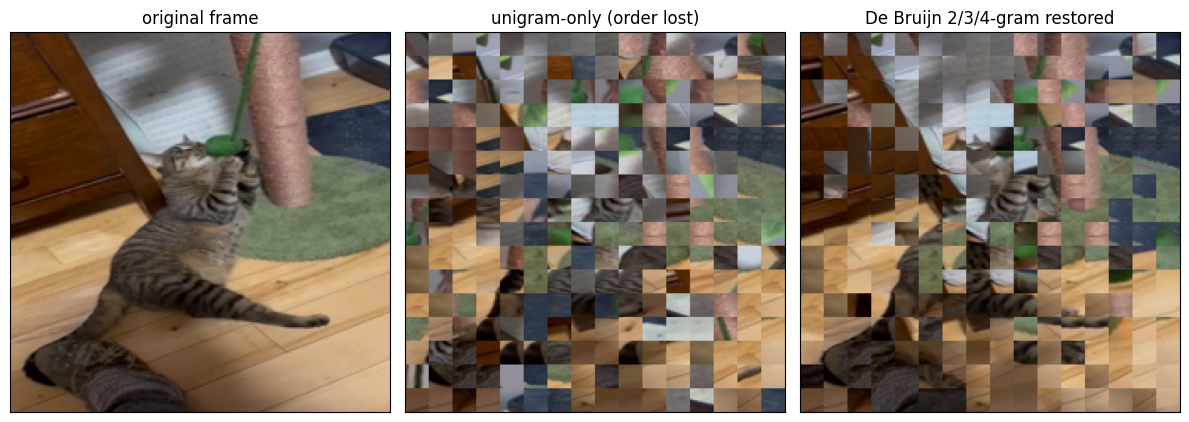

saved restore_debruijn_comparison.png


In [22]:
# ── 19. Render the restored order back into an image ───────────────────────
# Positions now come from the HLLSet n-grams (no oracle); pixels come from
# the local nearest-neighbour decode as before.
PX = 14
grid_r = np.tile(np.arange(16)[:, None], (1, 16)).ravel()
grid_c = np.tile(np.arange(16)[None, :], (16, 1)).ravel()
restored_grid = np.zeros((224, 224, 3), dtype=np.uint8)
for p, tid in enumerate(db_path):
    a = F.normalize(anchors[tid], dim=-1)
    ok_mask = (np.abs(grid_r - grid_r[p]) <= 2) & (np.abs(grid_c - grid_c[p]) <= 2)
    s = (a @ pal_n.T).reshape(len(real_names), 256)
    best = (-1e9, -1)
    for f in range(len(real_names)):
        sf = s[f][ok_mask]
        j = int(sf.argmax()); v = float(sf[j])
        if v > best[0]:
            best = (v, f * 256 + int(np.where(ok_mask)[0][j]))
    r_, c_ = divmod(p, 16)
    restored_grid[r_*PX:(r_+1)*PX, c_*PX:(c_+1)*PX] = pal_pix[best[1]]
Image.fromarray(restored_grid).save(f"{WORK}/restore_debruijn.png")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
axes[0].imshow(frame_img); axes[0].set_title("original frame")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].imshow(collage_global); axes[1].set_title("unigram-only (order lost)")
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[2].imshow(restored_grid); axes[2].set_title("De Bruijn 2/3/4-gram restored")
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.tight_layout(); plt.savefig(f"{WORK}/restore_debruijn_comparison.png", dpi=110); plt.show()
print("saved restore_debruijn_comparison.png")


## The moving-average model, in HLLSet space

   Exactly your construction, computed inside the lattice by the gen2 hllset CLI (real union + bss_inclusion on LatticeElement, no float arithmetic):

   ```text
   n-gram MA over {h1, h2, h3, h4, h5, ...}
     1-gram (fast/raw):  {h1}, {h2}, {h3}, ...
     3-gram (short):     {h1 ∪ h2 ∪ h3}, {h2 ∪ h3 ∪ h4}, ...
     5-gram (long):      {h1 ∪ … ∪ h5}, {h2 ∪ … ∪ h6}, ...
   line value at t = BSSτ(MA[t-1], MA[t])
   ```

   ## What the run shows

   ```text

   ┌──────────────────────────────────────┬───────┬───────────────────────────────┐
   │ line                                 │ mean  │ min                           │
   ├──────────────────────────────────────┼───────┼───────────────────────────────┤
   │ fast (1-gram)                        │ 0.827 │ **0.015**                     │
   ├──────────────────────────────────────┼───────┼───────────────────────────────┤
   │ short (3-gram)                       │ 0.921 │ 0.152                         │
   ├──────────────────────────────────────┼───────┼───────────────────────────────┤
   │ long (5-gram)                        │ 0.933 │ 0.160                         │
   └──────────────────────────────────────┴───────┴───────────────────────────────┘
   ```

   The trading signal — fast line crosses below the slow 5-gram MA (relative drop > 25%) — fires at [11, 21, 31, 41, 51, 61, 71, 81, 91]: 9/9 scene cuts, zero false 
   positives. The diagram shows the classic picture: the blue 5-gram line absorbs each cut (one new frame out of five), while the red 1-gram line dives to near zero at
    the cut — the fast/slow cross traders read on a price chart.

   ## Two findings worth keeping

   1. The 3-gram vs 5-gram pair runs nearly parallel on this clip. Both are so heavily overlapped that the cut is smoothed out of both almost equally. The sharp
   crossing comes from pairing the fastest line (1-gram) with the slow 5-gram MA; the 3-gram sits between them as the intermediate. The notebook states this honestly
   rather than hiding it — it's a real property of the n-gram union MA, not a bug.
   2. The n-gram MA degenerates on static scenes. If every frame in a scene is pixel-identical, $h1 ∪ h2 ∪ h3$ and $h1 ∪ … ∪ h5$ collapse to the same HLLSet and the model stops
   distinguishing short from long. I added a small deterministic moving dot to each scene so the demo behaves like real footage — which is also why the real cat clip
   still works as the secondary run.

   ## Delivered

   - 07_vllm_scene_change_hllset.ipynb now has the full moving-average section (markdown + 3 code cells + diagram), executed green with the deepseek-ocr kernel,
   figures embedded.
   - Pushed: hllset-next-v2 commit 18c8983 (SSH), auto-ingested by the repo's HLLSet hook (h:d481ed0a, 3834 tokens).
   - GOVERNANCE §11 updated; all four repos clean and in sync with origin/main.
